<a href="https://colab.research.google.com/github/AfzalNavas/northstar-analytics/blob/main/notebooks/R_ANALTICS_SECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
install.packages("tidyverse")

library(tidyverse)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [ ]:
deliveries <- read.csv("https://raw.githubusercontent.com/AfzalNavas/northstar-analytics/refs/heads/main/Cleaned%20CSV/clean_deliveries.csv")
complaints <- read.csv("https://raw.githubusercontent.com/AfzalNavas/northstar-analytics/refs/heads/main/Cleaned%20CSV/clean_complaints.csv")
customers  <- read.csv("https://raw.githubusercontent.com/AfzalNavas/northstar-analytics/refs/heads/main/Cleaned%20CSV/clean_customers.csv")
orders     <- read.csv("https://raw.githubusercontent.com/AfzalNavas/northstar-analytics/refs/heads/main/Cleaned%20CSV/clean_orders.csv")

In [ ]:
complaint_count <- complaints %>%
  count(customer_id)

cus_data <- customers %>%
  inner_join(complaint_count, by = "customer_id")

print(" the first rows of the new transformed dataset:")
head(cus_data)

[1] " the first rows of the new transformed dataset:"


,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status,n
,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<int>
1,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active,2
2,C0004,75,Central,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active,2
3,C0010,23,West,Consumer,2025-10-07 20:37:00,87.2,48.6,Phone,Active,1
4,C0012,60,Airport,Consumer,2025-02-10 01:14:00,46.3,74.4,App,Active,2
5,C0013,30,East,Enterprise,2024-02-17 17:54:00,31.3,51.7,App,Active,1
6,C0014,62,North,Consumer,2024-05-16 09:26:00,94.1,81.0,App,Active,1


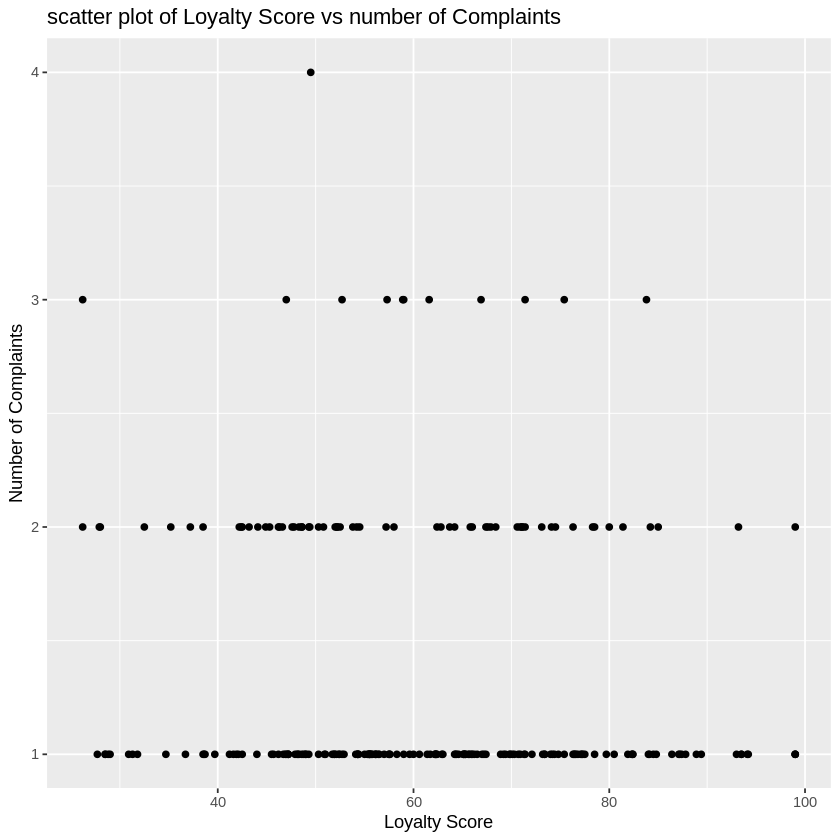

In [ ]:
ggplot(cus_data, aes(x = loyalty_score, y = n)) + geom_point() +
  labs(title = "scatter plot of Loyalty Score vs number of Complaints", x = "Loyalty Score", y = "Number of Complaints")

In [ ]:
cor_test <- cor.test(cus_data$loyalty_score, cus_data$n)

cor_results <- data.frame(
  Estimate = cor_test$estimate,
  p_value = cor_test$p.value)

print("the final results for correlation:")
print(cor_results)



[1] "the final results for correlation:"
      Estimate   p_value
cor -0.1046378 0.1111572


In [ ]:
lm_model <- lm(n ~ loyalty_score, data = cus_data)
lm_summary <- coef(summary(lm_model))

print("using the linear regression model:")
print(lm_summary)

[1] "using the linear regression model:"
                  Estimate  Std. Error   t value     Pr(>|t|)
(Intercept)    1.604735778 0.149817836 10.711247 5.351228e-22
loyalty_score -0.003803409 0.002378415 -1.599136 1.111572e-01


In [ ]:
actual_values <- cus_data$n

predictions <- predict(lm_model, cus_data)

squared_diff <- (actual_values - predictions)^2

mse <- mean(squared_diff, na.rm = TRUE)

print("the mean squared error of the Model (MSE):")
print(mse)

[1] "the mean squared error of the Model (MSE):"
[1] 0.3502642


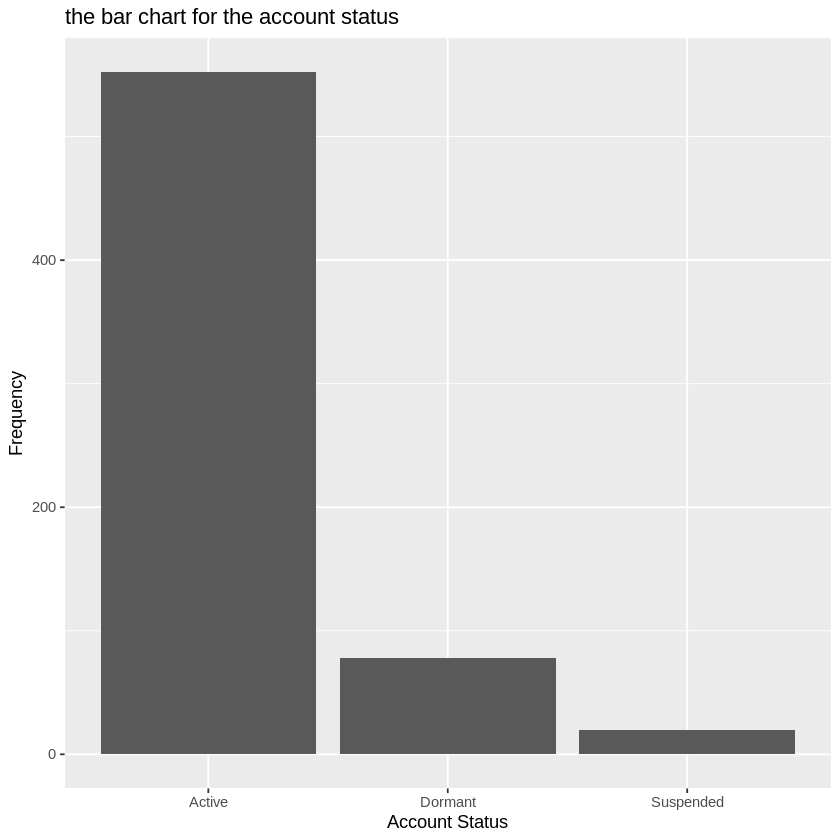

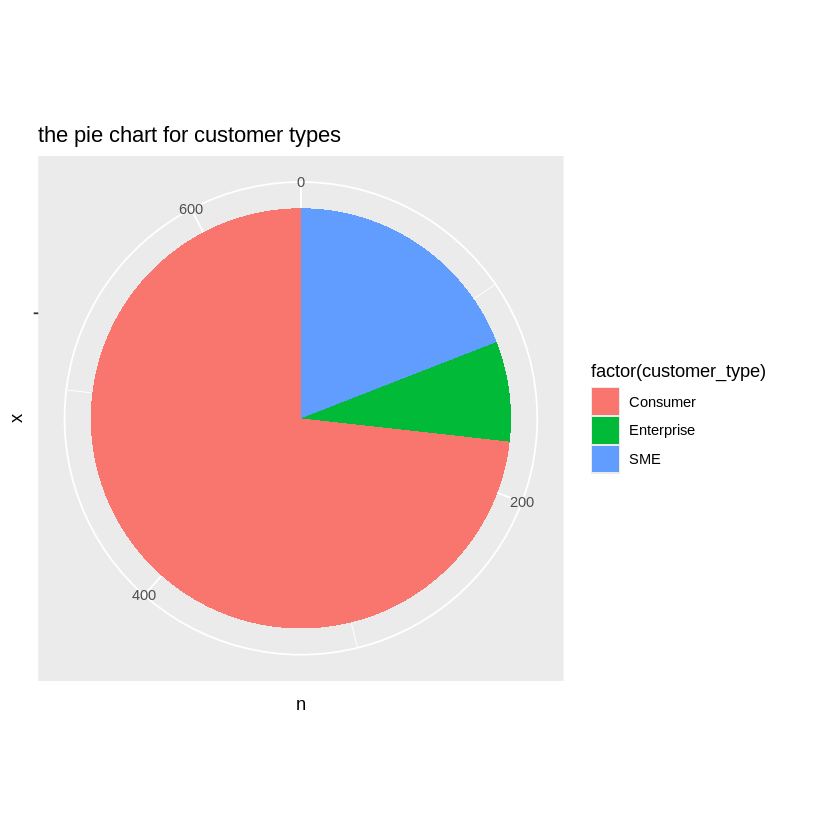

In [ ]:
ggplot(customers, aes(x = factor(account_status))) + geom_bar() +
  labs(title = "the bar chart for the account status", x = "Account Status", y = "Frequency")

customers %>%
  count(customer_type) %>%
  ggplot(aes(x = "", y = n, fill = factor(customer_type))) + geom_bar(stat = "identity", width = 1) + coord_polar("y", start = 0) +
  labs(title = "the pie chart for customer types")

In [ ]:
summary_data <- orders %>%
  select(order_value) %>%
  summarise_all(list(mean = mean, sd = sd, min = min, max = max))

print("the total summary statistics for the order values:")
print(summary_data)

[1] "the total summary statistics for the order values:"
      mean       sd  min    max
1 91.05052 60.91778 2.04 510.06
